In [1]:
from scipy.stats import norm
import numpy as np
from matplotlib import pyplot as plt

from common import van_der_corput, result, box_muller, bsm_St, bsm_d1_d2

In [2]:
def Put(s0: float, z: float, sigma: float, r: float, T: float, K: float) -> float:
	temp = s0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*z)
	if temp < K:
		return np.exp(-r*T)*(K - temp)
	else:
		return 0.0

def compute_greeks(S: float, K: float, T: float, r: float, sigma: float) -> tuple[float, float, float]:
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    delta = norm.cdf(d1) - 1
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * np.sqrt(T) * norm.pdf(d1)
    return delta, gamma, vega

In [3]:
#paramètres nouveaux
s0 = 1.0
K = 0.8
r = 0.02
t = 0
T = 4.0
sigma = 0.3

h = 0.001
m = 50000

# 4.1 Méthode numérique

## 4.1.1 Finite difference method

In [4]:
list_delta = []
list_gamma = []
list_vega = []

for i in range(1, m + 1):
	u = van_der_corput(i, base=2)
	z = norm.ppf(u)

	p_s_plus  = Put(s0 + h, z, sigma, r, T, K)
	p_s_minus = Put(s0 - h, z, sigma, r, T, K)
	p_s_ref   = Put(s0, z, sigma, r, T, K)

	p_sig_plus  = Put(s0, z, sigma + h, r, T, K)
	p_sig_minus = Put(s0, z, sigma - h, r, T, K)


	list_delta.append((p_s_plus - p_s_minus) / (2 * h))
	list_gamma.append((p_s_plus - 2 * p_s_ref + p_s_minus) / (h**2))
	list_vega.append((p_sig_plus - p_sig_minus) / (2 * h))
list_delta=np.array(list_delta).reshape(m,1)
list_gamma=np.array(list_gamma).reshape(m,1)
list_vega=np.array(list_vega).reshape(m,1)

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: -0.2103476873599426
std: 0.2650814098937421
------------------------------


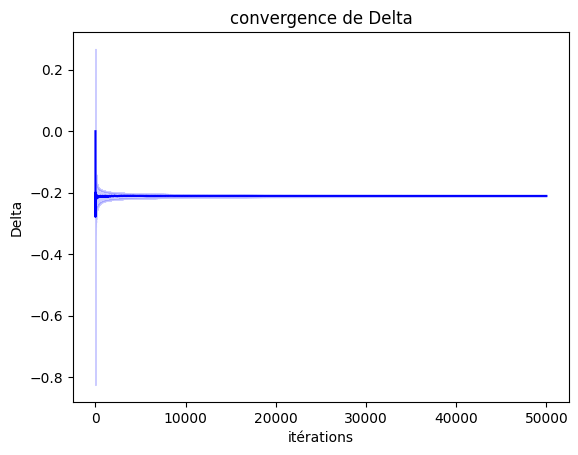

In [5]:
result([list_delta],log=False,global_title="convergence de Delta",y_title="Delta")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.48045202294468276
std: 15.34558230895506
------------------------------


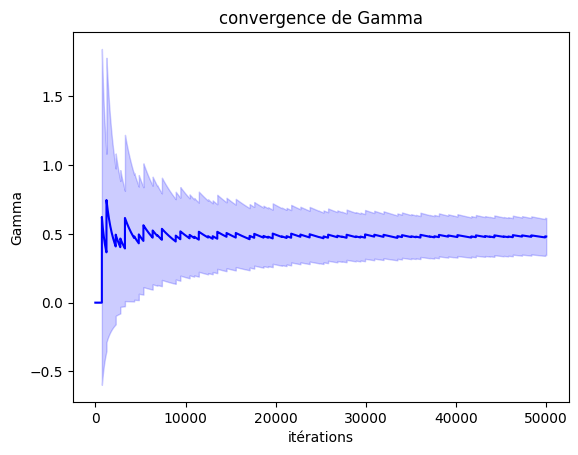

In [6]:
result([list_gamma],log=False,global_title="convergence de Gamma",y_title="Gamma")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.5769942422359893
std: 0.6820011935456258
------------------------------


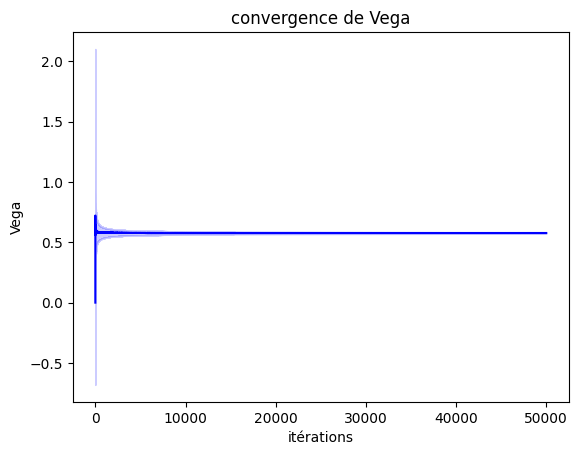

In [7]:
result([list_vega],log=False,global_title="convergence de Vega",y_title="Vega")

## 4.1.2 Pathwise differentation

In [8]:
list_delta_pw = []
list_vega_pw = []

for i in range(1, m + 1):
	u = van_der_corput(i, base=2)
	z = norm.ppf(u)

	st = s0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * z)

	if st < K:
		disc = np.exp(-r * T-t)

		deriv_st_sigma = st * (np.sqrt(T) * z - sigma * T)

		list_delta_pw.append(disc * (-1.0) * (st / s0))
		list_vega_pw.append(disc * (-1.0) * deriv_st_sigma)
	else:
		list_delta_pw.append(0.0)
		list_vega_pw.append(0.0)
list_delta_pw=np.array(list_delta_pw).reshape(m,1)
list_vega_pw=np.array(list_vega_pw).reshape(m,1)

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: -0.210338621938285
std: 0.26529925375308533
------------------------------


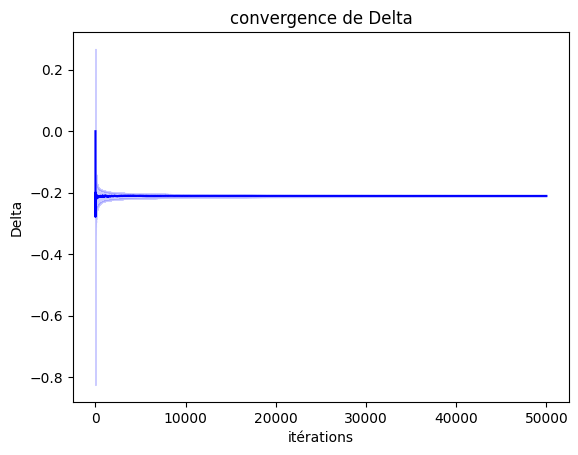

In [9]:
result([list_delta_pw],log=False,global_title="convergence de Delta",y_title="Delta")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.5769830539924161
std: 0.6823653849469993
------------------------------


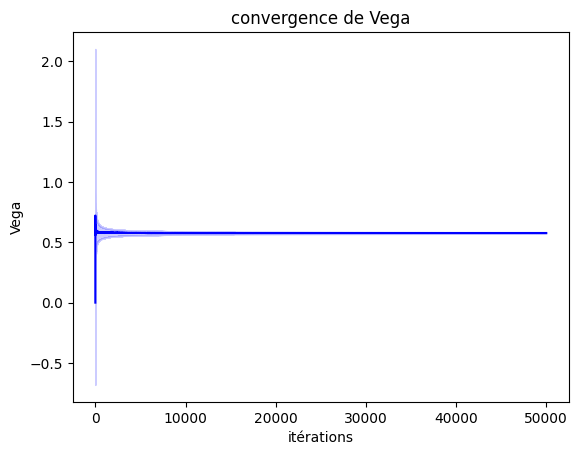

In [10]:
result([list_vega_pw],log=False,global_title="convergence de Vega",y_title="Vega")

## 4.1.3 Log likelihood method

In [11]:
# Generation de la normale (On en utilise 2 war on a du WT**2)
u1 = np.array([van_der_corput(i, 2) for i in range(1, m + 1)])
u2 = np.array([van_der_corput(i, 3) for i in range(1, m + 1)])
Z = box_muller(u2,u1)[0]
WT = np.sqrt(T) * Z

# formules Put donnée
ST=bsm_St(s0,r,sigma,1,m,T,t,Z=Z.reshape(m,1)).transpose()
payoff = np.maximum(K - ST, 0)
df = np.exp(-r * T)


# Greeks démontrés dans le devoir
delta = (df * payoff * (WT / (s0 * sigma * T))).reshape(m,1)
vega  = (df * payoff * ((WT**2 - T)/(sigma * T) - WT)).reshape(m,1)
gamma = (df * payoff * (1/(s0**2 * sigma * T)) * (WT**2/(sigma*T) - WT - 1/sigma)).reshape(m,1)

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: -0.21038999785668194
std: 0.4398374520179566
------------------------------


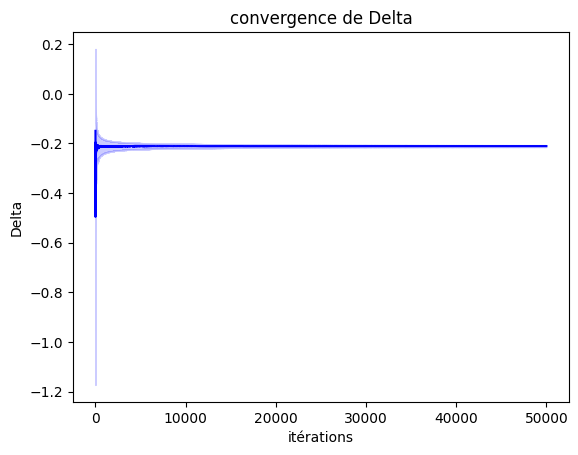

In [12]:
result([delta],log=False,global_title="convergence de Delta",y_title="Delta")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.4810407847298641
std: 1.703423601722852
------------------------------


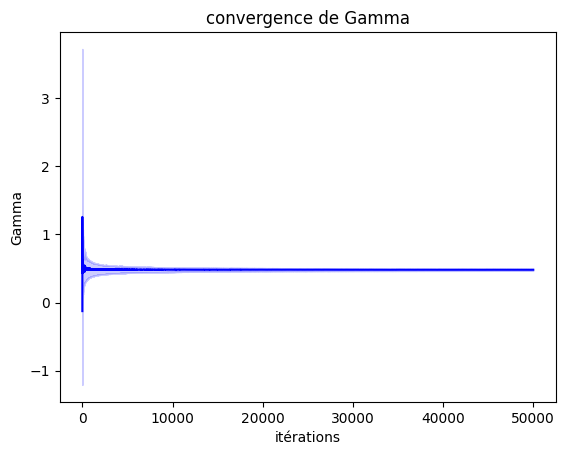

In [13]:
result([gamma],log=False,global_title="convergence de Gamma",y_title="Gamma")

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.5772489416758312
std: 2.04410832206743
------------------------------


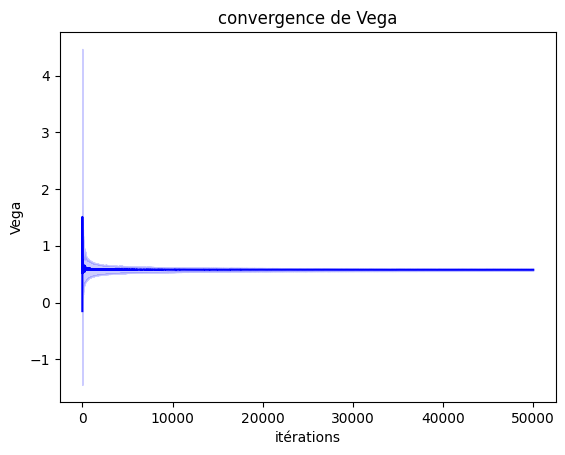

In [14]:
result([vega],log=False,global_title="convergence de Vega",y_title="Vega")

# 4.3 Variation

In [15]:
S_range = np.linspace(0.1, 2.0, 100)
deltas, gammas, vegas_vs_s = [], [], []

for s in S_range:
    d, g, v = compute_greeks(s, K, T, r, sigma)
    deltas.append(d)
    gammas.append(g)
    vegas_vs_s.append(v)

sigma_range = np.linspace(0.01, 0.8, 100)
vegas_vs_sigma = [compute_greeks(1.0, K, T, r, sig)[2] for sig in sigma_range]

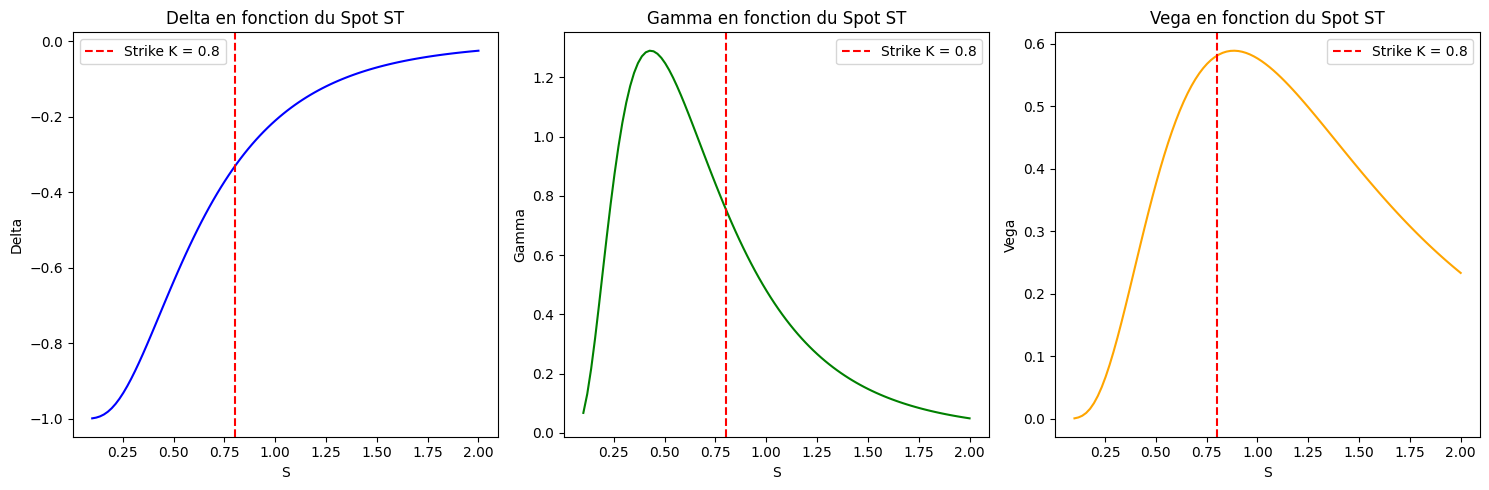

In [16]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(S_range, deltas, color='blue')
plt.title('Delta en fonction du Spot ST')
plt.xlabel('S'); plt.ylabel('Delta')
plt.axvline(x=K, color='red', linestyle='--', label='Strike K = ' + str(K))
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(S_range, gammas, color='green')
plt.title('Gamma en fonction du Spot ST')
plt.xlabel('S'); plt.ylabel('Gamma')
plt.axvline(x=K, color='red', linestyle='--', label='Strike K = ' + str(K))
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(S_range, vegas_vs_s, color='orange')
plt.title('Vega en fonction du Spot ST')
plt.xlabel('S'); plt.ylabel('Vega')
plt.axvline(x=K, color='red', linestyle='--', label='Strike K = ' + str(K))
plt.legend()

plt.tight_layout()
plt.show()

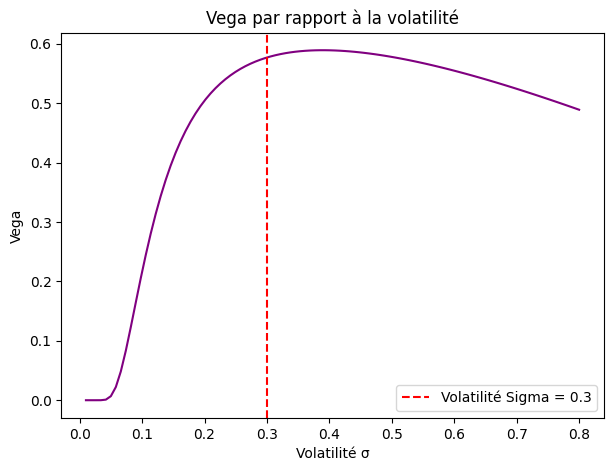

In [17]:
plt.figure(figsize=(7, 5))
plt.plot(sigma_range, vegas_vs_sigma, color='purple')
plt.title('Vega par rapport à la volatilité')
plt.xlabel('Volatilité σ'); plt.ylabel('Vega')
plt.axvline(x=sigma, color='red', linestyle='--', label='Volatilité Sigma = '+str(sigma))
plt.legend()
plt.show()

# 4.4 Réduction de variance : Importance sampling

In [18]:
K_bis = 0.4

mu = (np.log(K_bis / s0) - r * T) / (sigma * np.sqrt(T))

u = np.array([van_der_corput(i,2) for i in range(1, m + 1)])
z_q = norm.ppf(u) + mu

# Poids de correction L^-1 = dP/dQ
weight = np.exp(-mu * z_q + 0.5 * mu**2)
# Dynamiques sous Q
ST=bsm_St(s0,r,sigma,1,m,T,t,Z=z_q.reshape(m,1)).transpose()
payoff = np.exp(-r * T) * np.maximum(K_bis - ST, 0)



# Delta PW
delta_pw = np.mean(np.where(ST < K_bis, -np.exp(-r * T) * (ST / s0), 0) * weight)

# Vega PW
vega_pw = np.mean(np.where(ST < K_bis, -np.exp(-r * T) * ST * (np.sqrt(T) * z_q - sigma * T), 0) * weight)

# Gamma Likelihood
score_gamma = (z_q**2 - 1) / (s0**2 * sigma**2 * T) - z_q / (s0**2 * sigma * np.sqrt(T))
gamma_like = np.mean(payoff * score_gamma * weight)

# BS formule fermées
d1 = bsm_d1_d2(s0,K_bis,r,sigma,T,t)[0]
delta_bs = norm.cdf(d1) - 1
gamma_bs = norm.pdf(d1) / (s0 * sigma * np.sqrt(T))
vega_bs = s0 * np.sqrt(T) * norm.pdf(d1)

print(f"mu: {mu}")
print("--------------------")
print(f"Résultats IS (K={K_bis})")
print("--------------------")
print(f"Delta PW: {delta_pw} | BS: {delta_bs}")
print(f"Vega PW:  {vega_pw}  | BS: {vega_bs}")
print(f"Gamma LR: {gamma_like} | BS: {gamma_bs}")
print("erreur de chaque méthode:")
print(f"Delta PW erreur: {abs(delta_pw - delta_bs)}")
print(f"Vega PW erreur:  {abs(vega_pw - vega_bs)}")
print(f"Gamma LR erreur: {abs(gamma_like - gamma_bs)}")

mu: -1.6604845531235917
--------------------
Résultats IS (K=0.4)
--------------------
Delta PW: -0.024967537619730414 | BS: -0.024969590849970746
Vega PW:  0.11676302335844242  | BS: 0.11677092210499923
Gamma LR: 0.0973123735092365 | BS: 0.09730910175416603
erreur de chaque méthode:
Delta PW erreur: 2.0532302403321323e-06
Vega PW erreur:  7.898746556808667e-06
Gamma LR erreur: 3.2717550704636222e-06
